In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import os
import contextily as ctx
from airquality import datamodules as datamodules

In [2]:
id = 'airquality_coi_daily'
config = datamodules.spec(id).default_config.copy()
config['preprocessing_config']['threshold'] = 100
datamodule = datamodules.make('airquality_coi_daily', **config)
datamodule.setup('none')

In [3]:
datamodule.df['TotalPrecipitation'].describe()

count    76902.000000
mean         3.148827
std          9.007539
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        149.600000
Name: TotalPrecipitation, dtype: float64

In [4]:
datamodule.df.columns

Index(['date_local', 'ZCTA5CE20', 'CO', 'NO2', 'SO2', 'O3', 'PM25', 'PM10',
       'Smoke', 'AQI', 'AverageDryBulbTemperature', 'AverageRelativeHumidity',
       'AverageStationPressure', 'AverageWindSpeed', 'TotalPrecipitation',
       'HeatIndex', 'positive_covid_tests', 'SVI_socioeco_perc',
       'SVI_household_perc', 'SVI_racial_ethnic_perc', 'SVI_housing_perc',
       'SVI_overall_perc', 'EP_POV150', 'EP_UNEMP', 'EP_HBURD', 'EP_NOHSDP',
       'EP_UNINSUR', 'EP_AGE65', 'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT',
       'EP_LIMENG', 'EP_MINRTY', 'EP_MUNIT', 'EP_MOBILE', 'EP_CROWD',
       'EP_NOVEH', 'EP_GROUPQ', 'EPL_POV150', 'EPL_UNEMP', 'EPL_HBURD',
       'EPL_NOHSDP', 'EPL_UNINSUR', 'EPL_AGE65', 'EPL_AGE17', 'EPL_DISABL',
       'EPL_SNGPNT', 'EPL_LIMENG', 'EPL_MINRTY', 'EPL_MUNIT', 'EPL_MOBILE',
       'EPL_CROWD', 'EPL_NOVEH', 'EPL_GROUPQ', 'EP_NOINT', 'EP_AFAM',
       'EP_HISP', 'EP_ASIAN', 'EP_AIAN', 'EP_NHPI', 'EP_TWOMORE',
       'EP_OTHERRACE', 'COI_overall_perc', 'COI_educ

In [5]:
from airquality.analysis.plotting import labels_map

exposures = datamodule.df[['NO2', 'SO2', 'CO', 'PM25', 'PM10','HeatIndex', 'AverageDryBulbTemperature', 'AverageRelativeHumidity', 'TotalPrecipitation','SVI_overall_perc', 'COI_overall_perc' ]].copy()
for col in exposures:
    exposures[col] = exposures[col] * datamodule.iqr[col]
exposures['SVI_overall_perc'] *= 100
exposures = exposures.describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95])

outcomes = datamodule.df.groupby('date_local')[['visits']].sum().describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95])

weekly = datamodule.df.copy()
weekly.date_local = weekly.date_local.dt.asfreq('W', how='start')
outcomes_week = weekly.groupby('date_local')[['visits']].sum().describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95])

descriptive = pd.concat([
    exposures.rename(columns=labels_map).T.drop(columns=['min', 'max', 'count', 'mean', 'std']),
    outcomes.T.drop(columns=['count', 'mean', 'std', 'min', 'max']),
    outcomes_week.T.drop(columns=['count', 'mean', 'std', 'min', 'max'])
])
print(descriptive.to_latex(float_format='{:.2f}'.format))

descriptive

\begin{tabular}{lrrrrrrr}
\toprule
 & 5% & 10% & 25% & 50% & 75% & 90% & 95% \\
\midrule
NO$_2$ (ppb) & 1.99 & 2.54 & 3.53 & 5.14 & 7.46 & 10.64 & 13.16 \\
SO$_2$ (ppb) & 0.06 & 0.10 & 0.20 & 0.37 & 0.64 & 0.88 & 1.02 \\
CO (ppm) & 0.11 & 0.14 & 0.19 & 0.24 & 0.31 & 0.37 & 0.41 \\
PM$_{2.5}$ ($\mu$g/m$^3$) & 3.46 & 3.92 & 4.87 & 6.26 & 8.15 & 10.25 & 12.11 \\
PM$_{10}$ ($\mu$g/m$^3$) & 4.84 & 5.77 & 8.07 & 10.92 & 13.60 & 16.52 & 19.00 \\
Heat Index ($^{\circ}$C) & 1.18 & 3.46 & 8.82 & 17.15 & 24.56 & 28.85 & 30.68 \\
Temperature ($^{\circ}$C) & 3.05 & 5.11 & 9.89 & 17.41 & 24.07 & 26.71 & 27.74 \\
Relative Humidity (%) & 50.06 & 55.82 & 65.39 & 74.67 & 82.92 & 89.05 & 91.99 \\
Precipitation (mm) & 0.00 & 0.00 & 0.00 & 0.00 & 1.00 & 10.40 & 19.10 \\
SVI (%) & 60.38 & 62.95 & 76.20 & 86.17 & 92.85 & 96.60 & 98.59 \\
COI (%) & 6.00 & 11.00 & 28.00 & 45.00 & 66.00 & 77.00 & 83.00 \\
visits & 1.00 & 2.00 & 3.00 & 6.00 & 9.00 & 13.00 & 15.00 \\
visits & 13.70 & 16.00 & 26.00 & 41.00 & 59.50

,5%,10%,25%,50%,75%,90%,95%
NO$_2$ (ppb),1.993818,2.536956,3.531204,5.137539,7.455362,10.642044,13.164789
SO$_2$ (ppb),0.058900,0.095451,0.197952,0.367858,0.639800,0.878537,1.016285
CO (ppm),0.109418,0.136364,0.192982,0.238716,0.306067,0.368484,0.412416
PM$_{2.5}$ ($\mu$g/m$^3$),3.460903,3.915893,4.871142,6.264968,8.145452,10.247314,12.107374
PM$_{10}$ ($\mu$g/m$^3$),4.840431,5.767794,8.065264,10.916379,13.597249,16.516667,19.000000
Heat Index ($^{\circ}$C),1.177755,3.455939,8.819821,17.147349,24.561887,28.850885,30.680756
Temperature ($^{\circ}$C),3.046116,5.105334,9.887424,17.408195,24.074047,26.706361,27.738873
Relative Humidity (%),50.061271,55.818495,65.389702,74.666847,82.924373,89.046179,91.988837
Precipitation (mm),0.000000,0.000000,0.000000,0.000000,1.000000,10.400000,19.100000
SVI (%),60.380000,62.950000,76.200000,86.170000,92.850000,96.600000,98.590000


In [6]:
# Print out the latex portion of the table
def format_num(num):
    if isinstance(num, float):
        return f'{num:.2f}'
    return str(num)

def format_row(row, index):
    return index + ' & '.join(format_num(value) for value in row) + ' \\\\'

for idx, row in descriptive.iterrows():
    idx = idx.replace('%', '\%')
    if idx in ['NO$_2$ (ppb)', 'SO$_2$ (ppb)', 'CO (ppm)']:
        print(idx + ' & ' + ' & '.join(f'{value:.2f}' for value in row) + ' \\\\')
    elif idx  == 'visits':
        print ('\midrule')
        idx = 'Daily Exacerbations'
        print(idx + ' & ' + ' & '.join(f'{value:.0f}' for value in row) + ' \\\\')
    else:
        print(idx + ' & ' + ' & '.join(f'{value:.1f}' for value in row) + ' \\\\')



NO$_2$ (ppb) & 1.99 & 2.54 & 3.53 & 5.14 & 7.46 & 10.64 & 13.16 \\
SO$_2$ (ppb) & 0.06 & 0.10 & 0.20 & 0.37 & 0.64 & 0.88 & 1.02 \\
CO (ppm) & 0.11 & 0.14 & 0.19 & 0.24 & 0.31 & 0.37 & 0.41 \\
PM$_{2.5}$ ($\mu$g/m$^3$) & 3.5 & 3.9 & 4.9 & 6.3 & 8.1 & 10.2 & 12.1 \\
PM$_{10}$ ($\mu$g/m$^3$) & 4.8 & 5.8 & 8.1 & 10.9 & 13.6 & 16.5 & 19.0 \\
Heat Index ($^{\circ}$C) & 1.2 & 3.5 & 8.8 & 17.1 & 24.6 & 28.9 & 30.7 \\
Temperature ($^{\circ}$C) & 3.0 & 5.1 & 9.9 & 17.4 & 24.1 & 26.7 & 27.7 \\
Relative Humidity (\%) & 50.1 & 55.8 & 65.4 & 74.7 & 82.9 & 89.0 & 92.0 \\
Precipitation (mm) & 0.0 & 0.0 & 0.0 & 0.0 & 1.0 & 10.4 & 19.1 \\
SVI (\%) & 60.4 & 62.9 & 76.2 & 86.2 & 92.8 & 96.6 & 98.6 \\
COI (\%) & 6.0 & 11.0 & 28.0 & 45.0 & 66.0 & 77.0 & 83.0 \\
\midrule
Daily Exacerbations & 1 & 2 & 3 & 6 & 9 & 13 & 15 \\
\midrule
Daily Exacerbations & 14 & 16 & 26 & 41 & 60 & 73 & 87 \\


In [12]:
datamodule.dataframes['patient_df']['PATIENT_AGE'].describe()

count    179021.000000
mean          4.382994
std           4.332465
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max          18.000000
Name: PATIENT_AGE, dtype: float64

In [15]:
gpd.read_file('/Users/jcolen/Documents/chkd_toy_problem/data/Hampton_Roads_ZCTA_Populations/Hampton_Roads_ZCTA_Populations.shp').columns

Index(['ZCTA5CE20', 'Total Popu', 'Population', 'geometry'], dtype='object')

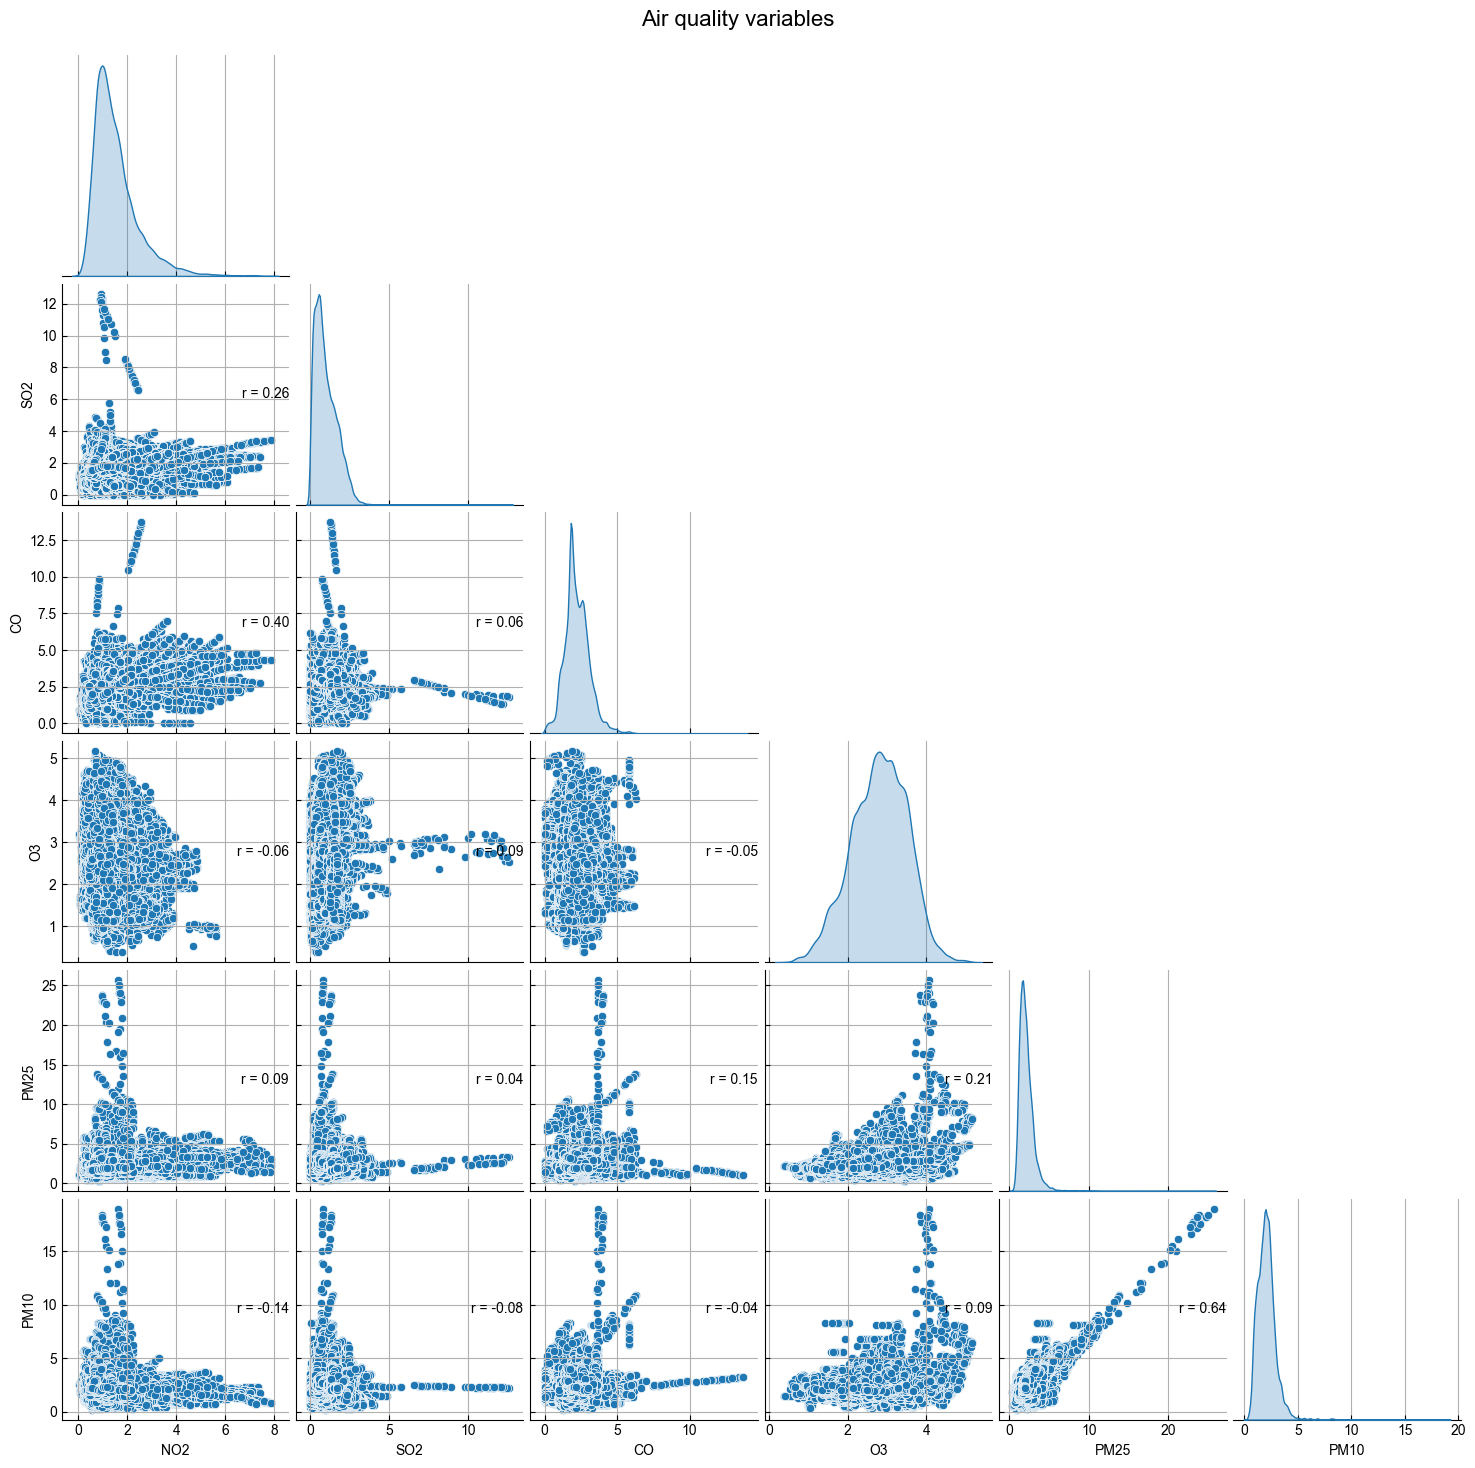

In [16]:
import seaborn as sns
from scipy.stats import pearsonr
from airquality.analysis.plotting import labels_map

def label_correlation(x, y, **kwargs):
    ax = plt.gca()
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    result = pearsonr(df['x'], df['y'])
    label = f"r = {result.statistic:.2f}"

    ax.text(1, 0.5, label, va='center', ha='right', transform=ax.transAxes)

g = sns.pairplot(datamodule.df, 
                 vars=['NO2', 'SO2', 'CO', 'O3', 'PM25', 'PM10'],
                 diag_kind='kde',
                 corner=True)
g.map_lower(label_correlation)
fig = plt.gcf()

fig.subplots_adjust(top=0.95)
fig.suptitle('Air quality variables', fontsize=16);

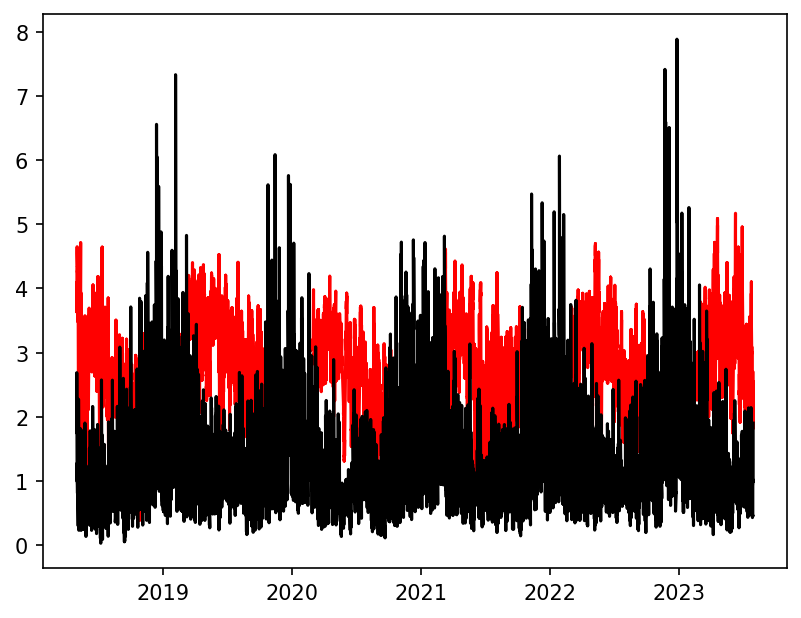

In [7]:
fig, ax = plt.subplots(1, 1, dpi=150)
ax.plot(datamodule.df['date_local'].dt.to_timestamp(), datamodule.df['O3'], color='red')
ax.plot(datamodule.df['date_local'].dt.to_timestamp(), datamodule.df['NO2'], color='black')
